Conectando directamente al servidor de la NOAA para el 2026-04-16 18:00:00 UTC...
El archivo ya existe, leyéndolo desde el disco.
Archivo cargado correctamente.
Carimbo ajustado y Bolivia centrada geográficamente.
¡Imágen generada con éxito y lista para compartir!: /Users/diegoperales/Meteorology/GOES/procesados/GOES19_IR_SENAMHI_Bolivia_Balanced_20260416_1805.png


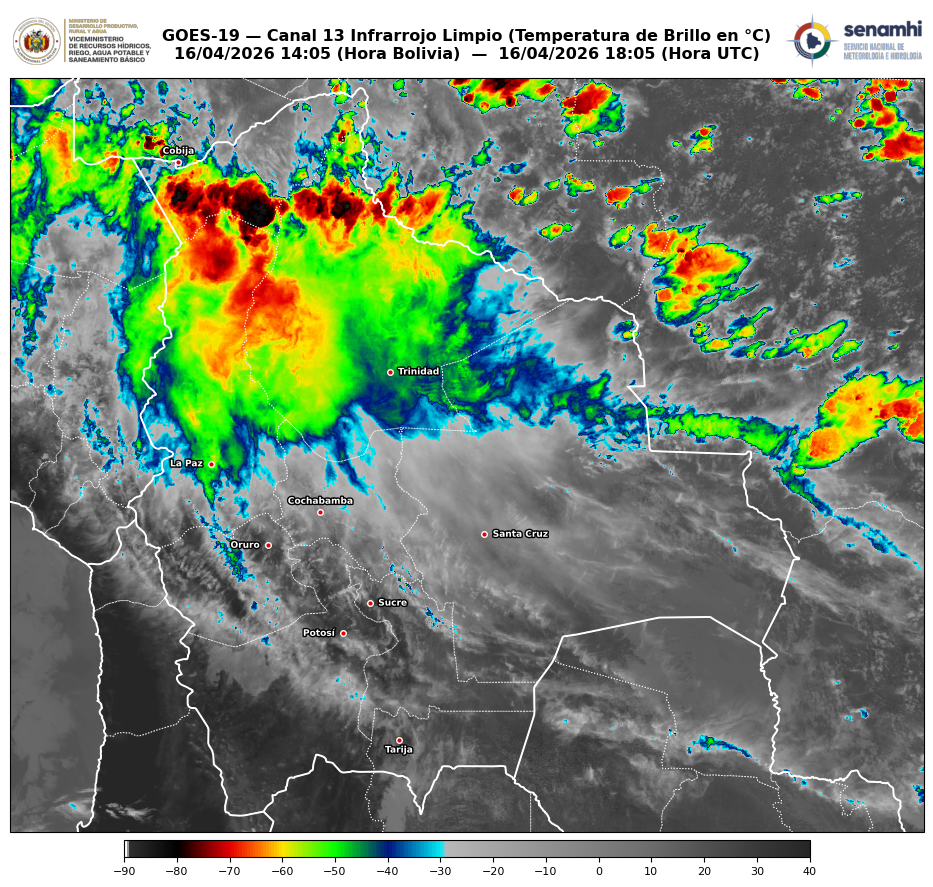

In [ ]:
import os
from datetime import datetime
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import s3fs

# ==========================================
# 1. CONFIGURACIÓN DEL USUARIO
# ==========================================
# Fecha y hora de la imágen satelital (Año, Mes, Día, Hora, Minutos [UTC])
FECHA_BUSCADA = datetime(2026, 4, 16, 18, 00) 

# Rutas locales
BASE_DIR = "/Users/diegoperales/Meteorology/GOES"
RAW_DATA = os.path.join(BASE_DIR, "raw_data")
OUTPUTS = os.path.join(BASE_DIR, "procesados")
os.makedirs(RAW_DATA, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)

# ==========================================
# 2. CONEXIÓN DIRECTA A AMAZON S3 (NOAA GOES)
# ==========================================
print(f"Conectando directamente al servidor de la NOAA para el {FECHA_BUSCADA} UTC...")

# Inicializar el sistema de archivos de Amazon (Anónimo porque es público)
fs = s3fs.S3FileSystem(anon=True)

# Construir la ruta en el servidor de la NOAA para el GOES-19
# El formato de la carpeta es: producto/año/día_del_año/hora/
doy = FECHA_BUSCADA.strftime('%j') # Día del año (001-366)
anio = FECHA_BUSCADA.strftime('%Y')
hora = FECHA_BUSCADA.strftime('%H')

# Ruta para el GOES-19, Producto ABI Nivel 2 Full Disk
s3_folder = f"noaa-goes19/ABI-L2-CMIPF/{anio}/{doy}/{hora}/"

try:
    # Listar todos los archivos en esa hora
    archivos = fs.ls(s3_folder)
    
    # Filtrar solo los que correspondan a la Banda 13
    archivos_b13 = [f for f in archivos if "M6C13" in f or "M3C13" in f]
    
    if not archivos_b13:
        raise FileNotFoundError(f"No se encontraron archivos de la Banda 13 para las {hora}:00 UTC.")
        
    # Seleccionamos el primer archivo disponible de esa hora
    s3_path = archivos_b13[0]
    file_name = s3_path.split('/')[-1]
    local_path = os.path.join(RAW_DATA, file_name)
    
    # Descarga física al disco duro
    if not os.path.exists(local_path):
        print(f"Descargando archivo: {file_name}...")
        fs.get(s3_path, local_path)
        print("Descarga completada.")
    else:
        print("El archivo ya existe, leyéndolo desde el disco.")
        
    # Abrir con Xarray
    ds = xr.open_dataset(local_path)
    print(f"Archivo cargado correctamente.")

except Exception as e:
    print(f"Error al conectar o buscar el archivo: {e}")
    print("Verifica si la fecha u hora existen, o si tienes conexión a internet.")
    raise e

# ==========================================
# 3. EXTRACCIÓN DE PARÁMETROS Y PROYECTO
# ==========================================
glob_attrs = ds.goes_imager_projection.attrs
height = glob_attrs['perspective_point_height']
lon_0 = glob_attrs['longitude_of_projection_origin']
sweep = glob_attrs['sweep_angle_axis']

dataprojenv = ccrs.Geostationary(central_longitude=lon_0, 
                                 satellite_height=height, 
                                 sweep_axis=sweep)

# Convertir de Kelvin a Celsius (La variable del canal es CMI)
temp_celsius = ds.CMI - 273.15

# ==========================================
# 4. GENERACIÓN DEL PRODUCTO VISUAL
# ==========================================
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.image as mpimg
from datetime import timedelta
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1. Rango estricto calibrado de la paleta de colores
VMIN = -90
VMAX = 40
rango_total = VMAX - VMIN 

def pos(temp):
    return (temp - VMIN) / rango_total

# Colores exactos de la plataforma RAAMB CIRA
colors_cira_exact = [
    (pos(-90), '#ffffff'),  # -90°C hacia abajo: Blanco ultra frío
    (pos(-89), '#2E2E2E'),  # -89°C: Gris transición tope extremo
    (pos(-80), '#000000'),  # -80°C: Gris casi negro muy frío
    (pos(-70), '#E50001'),  # -70°C: Rojo vivo
    (pos(-65), '#FE6602'),  # -65°C: Naranja
    (pos(-60), '#FEE500'),  # -60°C: Amarillo brillante
    (pos(-50), '#02FE00'),  # -50°C: Verde brillante
    (pos(-40), '#00157F'),  # -40°C: Azul oscuro
    (pos(-30), '#01EAF3'),  # -30°C: Cian / Celeste
    (pos(-29), '#B8B8B8'),  # -29°C: Gris muy claro
    (pos(0),   '#7E7E7E'),  #   0°C: Gris medio
    (pos(10),  '#6C6C6C'),  #  10°C: Gris medio-oscuro
    (pos(20),  '#525252'),  #  20°C: Gris oscuro
    (pos(30),  '#3A3A3A'),  #  30°C: Gris oscuro bajo
    (pos(40),  '#262626')   #  40°C: Negro/Gris tierra caliente
]

cmap_cira_perfecto = LinearSegmentedColormap.from_list('cira_rammb_exact', colors_cira_exact)

# 2. Configuración del lienzo inicial
fig, ax = plt.subplots(figsize=(10, 9.5), facecolor='white', 
                       subplot_kw={'projection': ccrs.PlateCarree()})

# Optimizamos los subplots
fig.subplots_adjust(left=0.01, right=0.99, top=0.88, bottom=0.06)

# --- AJUSTE GEOGRÁFICO EQUILIBRADO ---
ax.set_extent([-71.8, -55.2, -23.2, -9.5], crs=ccrs.PlateCarree())

# --- CAPA 1: IMAGEN SATELITAL ---
im = ax.pcolormesh(ds.x * height, ds.y * height, temp_celsius, 
                   transform=dataprojenv, cmap=cmap_cira_perfecto, vmin=VMIN, vmax=VMAX)

# --- CAPA 2: LÍMITES GEOGRÁFICOS ---
COLOR_BLANCO = '#ffffff'
ax.add_feature(cfeature.COASTLINE, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(cfeature.STATES, linestyle=(0, (1, 2)), edgecolor=COLOR_BLANCO, linewidth=0.7, zorder=4)

# --- CAPA 3: CAPITALES DE DEPARTAMENTO ---
import matplotlib.patheffects as patheffects  # Importación para el efecto de borde

# Diccionario con las coordenadas exactas de las 9 capitales de Bolivia
capitales = {
    "Cobija":        {"lat": -11.02, "lon": -68.74, "pos": "top"},
    "Trinidad":      {"lat": -14.83, "lon": -64.90, "pos": "right"},
    "La Paz":        {"lat": -16.50, "lon": -68.15, "pos": "left"},
    "Cochabamba":    {"lat": -17.38, "lon": -66.16, "pos": "top"},
    "Santa Cruz":    {"lat": -17.78, "lon": -63.18, "pos": "right"},
    "Oruro":         {"lat": -17.98, "lon": -67.11, "pos": "left"},
    "Sucre":         {"lat": -19.03, "lon": -65.26, "pos": "right"},
    "Potosí":        {"lat": -19.58, "lon": -65.75, "pos": "left"},
    "Tarija":        {"lat": -21.53, "lon": -64.73, "pos": "bottom"}
}

# Dibujamos los puntos y los nombres de las capitales
for ciudad, info in capitales.items():
    # 1. Dibujar el punto rojo con borde blanco y ajustar el tamaño (marksize)
    ax.plot(info["lon"], info["lat"], marker='o', color='#E50001', 
            markersize=4, markeredgecolor='white', markeredgewidth=1.0, 
            transform=ccrs.PlateCarree(), zorder=10)
    
    # 2. Ajuste del texto para que no se posicione sobre el punto
    offset_lon = 0.15 if info["pos"] == "right" else (-0.15 if info["pos"] == "left" else 0)
    offset_lat = 0.15 if info["pos"] == "top" else (-0.22 if info["pos"] == "bottom" else -0.05)
    
    alignment_h = "left" if info["pos"] == "right" else ("right" if info["pos"] == "left" else "center")
    
    # 3. Colocar el nombre y ajustar el tamaño del texto
    ax.text(info["lon"] + offset_lon, info["lat"] + offset_lat, ciudad,
            color='white', fontsize=6.5, fontweight='bold',
            horizontalalignment=alignment_h, transform=ccrs.PlateCarree(), zorder=11,
            path_effects=[patheffects.withStroke(linewidth=2, foreground='black')])

# --- CAPA 4: DOBLE HUSO HORARIO ---
fecha_utc = datetime.strptime(ds.t.dt.strftime('%Y-%m-%d %H:%M').item(), '%Y-%m-%d %H:%M')
fecha_bot = fecha_utc - timedelta(hours=4)

string_utc = fecha_utc.strftime('%d/%m/%Y %H:%M (Hora UTC)')
string_bot = fecha_bot.strftime('%d/%m/%Y %H:%M (Hora Bolivia)')

# --- CAPA 5: TÍTULO ---
ax.set_title(f"GOES-19 — Canal 13 Infrarrojo Limpio (Temperatura de Brillo en °C)\n{string_bot}  —  {string_utc}", 
             fontsize=11.5, fontweight='bold', pad=14, loc='center', linespacing=1.3)

# --- CAPA 6: BARRA DE COLORES DE REFERENCIA ---
# 1. Generamos el colorbar vinculándolo al mapa para mantener el efecto sin bordes
cbar = fig.colorbar(
    im, 
    orientation='horizontal', 
    pad=0.01,          # Pegado sutil abajo
    shrink=1.0,        # Forzamos ancho completo
    fraction=0.022,    # Conserva el grosor delgado
    aspect=40,         
    ax=ax              
)

# 2. Forzamos los ticks del Infrarrojo
valores_ticks = [-90, -80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40]
cbar.set_ticks(valores_ticks)
cbar.ax.tick_params(labelsize=8)

pos_cbar = cbar.ax.get_position()
cbar.ax.set_axes_locator(None) 
cbar.ax.set_position([
    0.00,              # Extremo izquierdo absoluto (0%)
    pos_cbar.y0,       # Conserva la altura vertical óptima
    1.00,              # Extremo derecho absoluto (100% de la pantalla)
    pos_cbar.height    # Conserva el grosor estilizado
])

# --- CAPA 7: POSICIONAMIENTO DINÁMICO DE LOGOS ---
PATH_LOGOS = os.path.join(BASE_DIR, "logos")
try:
    img_ministerio_path = os.path.join(PATH_LOGOS, "logo_ministerio.png")
    img_senamhi_path = os.path.join(PATH_LOGOS, "logo_senamhi.png")
    
    if os.path.exists(img_ministerio_path) and os.path.exists(img_senamhi_path):
        logo_ministerio = mpimg.imread(img_ministerio_path)
        logo_senamhi = mpimg.imread(img_senamhi_path)
        
        pos_mapa = ax.get_position()
        
        ax_logo_min = fig.add_axes([pos_mapa.x0, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_min.imshow(logo_ministerio)
        ax_logo_min.axis('off')
        
        ax_logo_sen = fig.add_axes([pos_mapa.x1 - 0.14, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_sen.imshow(logo_senamhi)
        ax_logo_sen.axis('off')
        print("Carimbo ajustado y Bolivia centrada geográficamente.")
except Exception as e:
    print(f"Alerta con logos: {e}")

# Guardado
output_name = f"{OUTPUTS}/GOES19_IR_SENAMHI_Bolivia_Balanced_{fecha_utc.strftime('%Y%m%d_%H%M')}.png"
plt.savefig(output_name, dpi=200, bbox_inches='tight', pad_inches=0.03)
print(f"¡Imágen generada con éxito y lista para compartir!: {output_name}")

plt.show()